## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Daniel Felipe Cardenas Romero" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Se requiere un sistema de análisis y gestión de rutas para una red de mensajería, modelado a través de un grafo no dirigido. En este sistema, los centros de distribución son los "vértices" (nodos) y las carreteras que los unen son las "aristas" (conexiones bidireccionales). Sirve para visualizar cómo están conectados los centros, encontrar los puntos más cercanos y trazar rutas de envío.

El ejercicio pide construir este sistema desde cero cumpliendo los siguientes puntos:

- Estructura de Datos (El Grafo): Construir la red inicial de 7 centros (del A al G) utilizando un diccionario en Python que funcione como una lista de adyacencia (donde cada centro tiene una lista de sus vecinos).


- Implementar Recorridos (BFS y DFS): 
    - BFS (Búsqueda a lo Ancho): Programarlo usando una cola. Su objetivo es explorar la red por "niveles" (qué centros están a 1 salto, a 2 saltos, etc.).

    - DFS (Búsqueda en Profundidad): Programarlo usando recursividad o una pila. Su objetivo es explorar un camino hasta el final antes de devolverse a buscar otras rutas.

- Interactividad (Menú y Selección): El programa no debe ser estático; el usuario debe poder escribir el nombre de cualquier centro para que los recorridos (BFS y DFS) arranquen desde ahí.

- Buscador de Rutas (GPS): Usando el algoritmo BFS, crear una función donde el usuario ingrese un centro de "Origen" y uno de "Destino", y el programa le imprima la ruta exacta y la cantidad de conexiones (saltos) para llegar.

- Expansión de la Red (Agregar nodos): El programa debe permitir crear un nuevo centro (ej. "H") en tiempo de ejecución, preguntarle al usuario con qué centros existentes se conecta, agregarlo al grafo bidireccionalmente, y volver a imprimir la red y los recorridos actualizados.


## 4) Diagramas de flujo **[5 pts]**

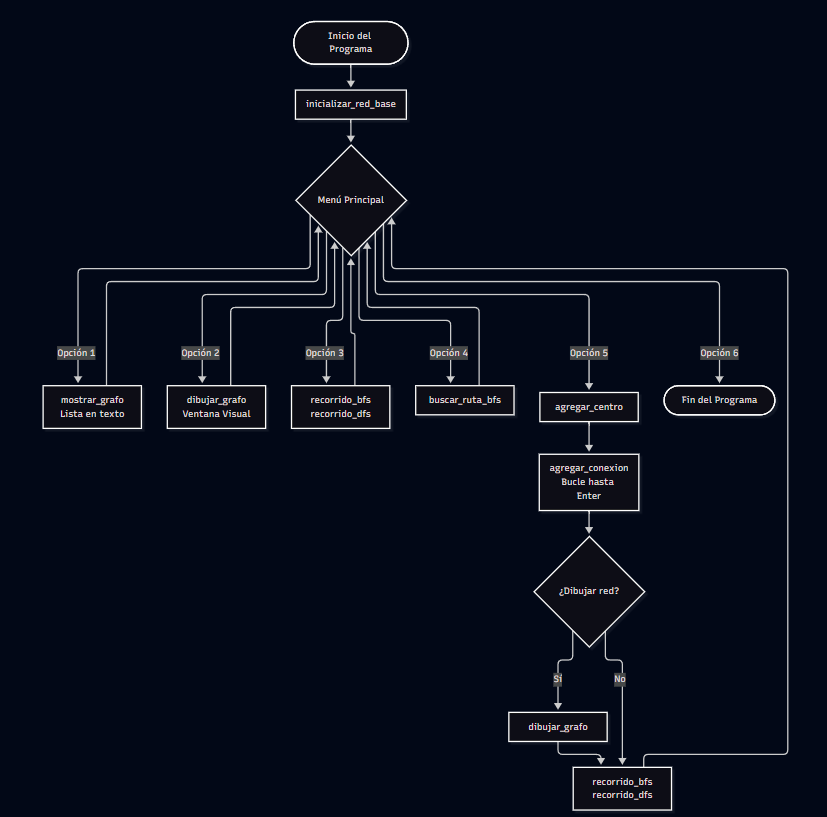

Inicio e Inicialización: El programa arranca creando los 7 centros iniciales y sus aristas llamando a inicializar_red_base().

El programa funciona bajo Menú que controla la interacción del usuario con la estructura del grafo:


- Opción 1 (Mostrar red): Imprime la lista de adyacencia iterando sobre el diccionario.

- Opcion 2 Ventana visual: Dibuja el grafo

- Opción 3 (Recorridos): Solicita un nodo de inicio y ejecuta secuencialmente los algoritmos de Búsqueda a lo Ancho (BFS) y Búsqueda en Profundidad (DFS).

- Opción 4 (Ruta corta): Utiliza una variante del BFS para encontrar el camino con menos saltos entre un nodo origen y uno destino.

- Opción 5 (Actualización de red): Permite agregar un nodo nuevo y entrar en un sub-ciclo para agregar múltiples conexiones a este nodo. Al finalizar presionando Enter, muestra la red actualizada y ejecuta los recorridos desde un nodo a elección.

- Opción 6: Rompe el ciclo principal y termina la ejecución.


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.



================= MENÚ RED DE MENSAJERÍA =================
1. Mostrar red de distribución (Lista de adyacencia)
2. Dibujar red de distribución (Ventana visual)
3. Realizar recorridos BFS y DFS (Seleccionando inicio)
4. Buscar un centro usando BFS (Ruta y conexiones)
5. Agregar nuevo centro y conexiones
6. Salir

Generando el gráfico... (cierra la ventana del gráfico para continuar)


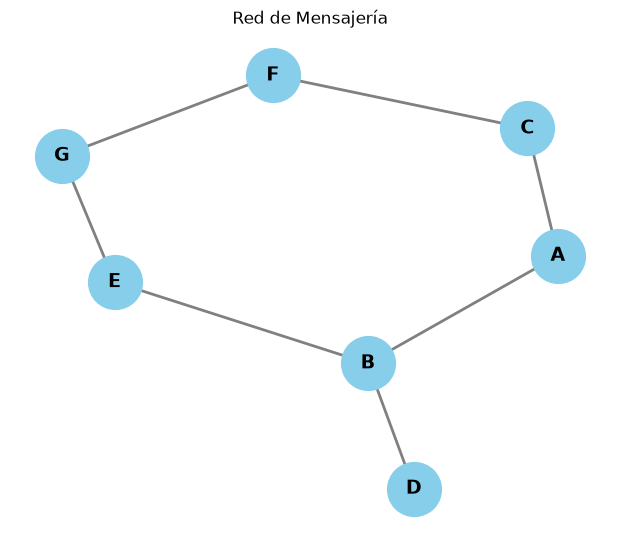


================= MENÚ RED DE MENSAJERÍA =================
1. Mostrar red de distribución (Lista de adyacencia)
2. Dibujar red de distribución (Ventana visual)
3. Realizar recorridos BFS y DFS (Seleccionando inicio)
4. Buscar un centro usando BFS (Ruta y conexiones)
5. Agregar nuevo centro y conexiones
6. Salir
Opción inválida. Intente de nuevo.

================= MENÚ RED DE MENSAJERÍA =================
1. Mostrar red de distribución (Lista de adyacencia)
2. Dibujar red de distribución (Ventana visual)
3. Realizar recorridos BFS y DFS (Seleccionando inicio)
4. Buscar un centro usando BFS (Ruta y conexiones)
5. Agregar nuevo centro y conexiones
6. Salir

--- Conexiones de la Red de Distribución ---
'A': ['B', 'C']
'B': ['A', 'D', 'E']
'C': ['A', 'F']
'D': ['B']
'E': ['B', 'G']
'F': ['C', 'G']
'G': ['E', 'F']
--------------------------------------------

================= MENÚ RED DE MENSAJERÍA =================
1. Mostrar red de distribución (Lista de adyacencia)
2. Dibujar red de dis

In [17]:

import networkx as nx
import matplotlib.pyplot as plt

# 1. FUNCIONES DE GESTIÓN DEL GRAFO (ESTRUCTURA DE DATOS)
def agregar_centro(grafo, centro):
    """Agrega un nuevo centro (vértice) al grafo si no existe."""
    if centro not in grafo:
        grafo[centro] = []
    else:
        print(f"El centro {centro} ya existe.")

def agregar_conexion(grafo, centro1, centro2):
    """Agrega una conexión entre dos centros."""
    if centro1 in grafo and centro2 in grafo:
        if centro2 not in grafo[centro1]:
            grafo[centro1].append(centro2)
        if centro1 not in grafo[centro2]:
            grafo[centro2].append(centro1)
    else:
        print("Error: Uno o ambos centros no existen.")

# 2. FUNCIONES DE VISUALIZACIÓN
def mostrar_grafo(grafo):
    """Imprime la lista de adyacencia del grafo."""
    print("\n--- Conexiones de la Red de Distribución ---")
    for centro, conexiones in grafo.items():
        print(f"'{centro}': {conexiones}")
    print("--------------------------------------------")

def dibujar_grafo(grafo):
    """Dibuja el grafo de forma visual en una nueva ventana."""
    print("\nGenerando el gráfico... (cierra la ventana del gráfico para continuar)")
    
    # Creamos un objeto de grafo no dirigido usando networkx
    G = nx.Graph()
    
    # Recorremos nuestro diccionario y agregamos los nodos y aristas al grafo visual
    for nodo, vecinos in grafo.items():
        G.add_node(nodo)
        for vecino in vecinos:
            G.add_edge(nodo, vecino)
            
    # Configuramos el dibujo y lo mostramos con matplotlib
    plt.figure(figsize=(6, 5))
    nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500, 
            font_size=14, font_weight='bold', edge_color='gray', width=2)
    plt.title("Red de Mensajería")
    plt.show()

# 3. ALGORITMOS DE RECORRIDO Y BÚSQUEDA
def recorrido_bfs(grafo, inicio):
    """Recorrido BFS usando una cola y mostrando niveles."""
    if inicio not in grafo:
        print(f"Error: El centro '{inicio}' no existe en la red.")
        return

    visitados = set([inicio])
    cola = [(inicio, 0)] 
    recorrido = []
    niveles = {}

    while cola:
        centro_actual, nivel_actual = cola.pop(0)
        recorrido.append(centro_actual)

        if nivel_actual not in niveles:
            niveles[nivel_actual] = []
        niveles[nivel_actual].append(centro_actual)

        for vecino in grafo[centro_actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append((vecino, nivel_actual + 1))

    print(f"\nRecorrido BFS desde {inicio}:")
    print(" -> ".join(recorrido))
    print("Niveles:")
    for nivel, centros in niveles.items():
        print(f"Nivel {nivel}: {', '.join(centros)}")

def dfs_recursivo(grafo, centro, visitados, recorrido):
    """Función para la recursividad del DFS."""
    visitados.add(centro)
    recorrido.append(centro)

    for vecino in grafo[centro]:
        if vecino not in visitados:
            dfs_recursivo(grafo, vecino, visitados, recorrido)

def recorrido_dfs(grafo, inicio):
    """Recorrido DFS implementado mediante recursividad."""
    if inicio not in grafo:
        print(f"Error: El centro '{inicio}' no existe en la red.")
        return

    visitados = set()
    recorrido = []
    
    dfs_recursivo(grafo, inicio, visitados, recorrido)
    print(f"\nRecorrido DFS desde {inicio}:")
    print(" -> ".join(recorrido))

def buscar_ruta_bfs(grafo, inicio, destino):
    """Buscar ruta más corta (en saltos) entre dos centros usando BFS."""
    if inicio not in grafo or destino not in grafo:
        print("Error: El centro inicial o de destino no existen.")
        return

    visitados = set([inicio])
    cola = [[inicio]] 

    while cola:
        ruta_actual = cola.pop(0)
        centro_actual = ruta_actual[-1]

        # Si llegamos al destino, devolvemos la ruta
        if centro_actual == destino:
            conexiones = len(ruta_actual) - 1
            print(f"\nCentro encontrado. Ruta: {' -> '.join(ruta_actual)}")
            print(f"Cantidad de conexiones: {conexiones}")
            return

        for vecino in grafo[centro_actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                nueva_ruta = list(ruta_actual)
                nueva_ruta.append(vecino)
                cola.append(nueva_ruta)

    print("\nNo existe una ruta hasta el centro solicitado.")

# 4. INICIALIZACIÓN DE DATOS (CONFIGURACIÓN BASE)
def inicializar_red_base():
    """Construye el grafo base propuesto en el enunciado."""
    grafo = {}
    centros = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    for rep in centros:
        agregar_centro(grafo, rep)

    conexiones = [
        ('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), 
        ('C', 'F'), ('E', 'G'), ('F', 'G')
    ]
    for origen, destino in conexiones:
        agregar_conexion(grafo, origen, destino)   
    return grafo

# 5. MAIN
def main():
    grafo = inicializar_red_base()
    while True:
        print("\n================= MENÚ RED DE MENSAJERÍA =================")
        print("1. Mostrar red de distribución (Lista de adyacencia)")
        print("2. Dibujar red de distribución (Ventana visual)")
        print("3. Realizar recorridos BFS y DFS (Seleccionando inicio)")
        print("4. Buscar un centro usando BFS (Ruta y conexiones)")
        print("5. Agregar nuevo centro y conexiones")
        print("6. Salir")
        print("==========================================================")
        opcion = input("Seleccione una opción: ")

        if opcion == '1':
            mostrar_grafo(grafo)
            
        elif opcion == '2':
            dibujar_grafo(grafo)

        elif opcion == '3':
            inicio = input("Ingrese el centro inicial para los recorridos: ").upper().strip()
            recorrido_bfs(grafo, inicio)
            recorrido_dfs(grafo, inicio)

        elif opcion == '4':
            inicio = input("Ingrese el centro inicial: ").upper().strip()
            destino = input("Ingrese el centro que desea buscar: ").upper().strip()
            buscar_ruta_bfs(grafo, inicio, destino)

        elif opcion == '5':
            nuevo_centro = input("Ingrese el nuevo centro (ej. H): ").upper().strip()
            agregar_centro(grafo, nuevo_centro)
            
            while True:
                conexion = input(f"Conectar {nuevo_centro} con (presione Enter para terminar): ").upper().strip()
                if conexion == "":
                    break
                agregar_conexion(grafo, nuevo_centro, conexion)
            
            print("\n--- Red actualizada ---")
            mostrar_grafo(grafo)
            
            # preguntamos si quiere dibujarlo tras actualizarlo
            dibujar = input("¿Desea dibujar la red actualizada? (S/N): ").upper().strip()
            if dibujar == 'S':
                dibujar_grafo(grafo)
            
            inicio = input("Seleccione el vértice desde el cual comenzarán los recorridos: ").upper().strip()
            recorrido_bfs(grafo, inicio)
            recorrido_dfs(grafo, inicio)

        elif opcion == '6':
            print("Saliendo del programa...")
            break
        else:
            print("Opción inválida. Intente de nuevo.")

main()


## 7) Tests aplicados **[15 pts]**

In [18]:
# Datos de prueba específicos para comprobar la estructura del grafo
centros_test = ['A', 'B', 'C', 'D']
conexiones_test = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('A', 'D')]
grafo_test = {}

# Construimos el grafo 
for centro in centros_test:
    agregar_centro(grafo_test, centro)

for origen, destino in conexiones_test:
    agregar_conexion(grafo_test, origen, destino)

# 1. Prueba de creación de los centros
assert len(grafo_test) == 4, f"Error: Se esperaban 4 centros, pero hay {len(grafo_test)}."
assert all(centro in grafo_test for centro in centros_test), "Error: Faltan centros en el grafo."

# 2. Prueba de conexiones bidireccionales
assert 'B' in grafo_test['A'], "Error: A no se conectó con B."
assert 'A' in grafo_test['B'], "Error: B no se conectó con A (Falla la bidireccionalidad)."

# 3. Prueba de cantidad de conexiones por vértice (deben tener 2)
assert len(grafo_test['C']) == 2, f"Error: C debería tener 2 conexiones, pero tiene {len(grafo_test['C'])}."

print("¡Todos los tests del grafo pasaron exitosamente!")

¡Todos los tests del grafo pasaron exitosamente!
